# FASHION MNIST
I will use the fashion mnist to practice the foundations of convolutional neural networks. Going from tensorflow dataset loading, basic image augmentation, model creation with the keras functional api, and GPU usage

## Techstack
* Tensorflow -> Deep learning and image data augmentation
* Numpy -> Basic array operations
* Scikit-learn -> metrics and confusion matrix

## Labels
| Label | Description   |
|-------|---------------|
| 0     | T-shirt/top   |
| 1     | Trouser       |
| 2     | Pullover      |
| 3     | Dress         |
| 4     | Coat          |
| 5     | Sandal        |
| 6     | Shirt         |
| 7     | Sneaker       |
| 8     | Bag           |
| 9     | Ankle boot    |

## Import Libraries

In [1]:
import tensorflow as tf
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.layers import Conv2D, Dropout, Flatten, Dense, Input, GlobalMaxPool2D, GlobalAvgPool2D, BatchNormalization, Activation
# keras image augmentation layers
from tensorflow.keras.layers import RandomFlip, RandomRotation, RandomBrightness, RandomZoom, RandomTranslation
from tensorflow.keras.models import Model

# keras optimizers
from tensorflow.keras.optimizers import Adam

# Learning rate reduce on plateau
from tensorflow.keras.callbacks import ReduceLROnPlateau

# Callbacks
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
# tensorflow image augmentation and data generator

import matplotlib.pyplot as plt
import numpy as np

# Check tensorflow version
print(f"TensorFlow Version: {tf.__version__}")

# Check GPU availability
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print(f"GPU available: {len(gpus)} GPUs found")
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
        print(f"  - {gpu}")
else:
    print("No GPU devices found. Using CPU.")

TensorFlow Version: 2.20.0
GPU available: 1 GPUs found
  - PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')


## Load image data

In [2]:
def load_fashion_mnist_data(val_split=0.1, to_tf_dataset=False):
    (train_images, train_labels), (test_images, test_labels) = fashion_mnist.load_data()

    # Normalize the images
    train_images = train_images / 255.0
    test_images = test_images / 255.0

    # expand dims of gray scale images
    train_images = tf.expand_dims(train_images, -1)
    test_images = tf.expand_dims(test_images, -1)

    # Split train
    val_size = int(len(train_images) * val_split)
    train_images, val_images = train_images[:-val_size], train_images[-val_size:]
    train_labels, val_labels = train_labels[:-val_size], train_labels[-val_size:]

    # Print size and shape
    print(f"Number of train images {len(train_images)} with shape: {train_images.shape}")
    print(f"Train labels: {train_labels.shape}")
    print(f"Number of val images {len(val_images)} with shape: {val_images.shape}")
    print(f"Val labels: {val_labels.shape}")
    print(f"Number of test images {len(test_images)} with shape: {test_images.shape}")
    print(f"Test labels: {test_labels.shape}")

    # transform into tensorflow dataset
    if to_tf_dataset:
      train_images = tf.data.Dataset.from_tensor_slices(train_images)
      train_labels = tf.data.Dataset.from_tensor_slices(train_labels)
      val_images = tf.data.Dataset.from_tensor_slices(val_images)
      val_labels = tf.data.Dataset.from_tensor_slices(val_labels)
      test_images = tf.data.Dataset.from_tensor_slices(test_images)
      test_labels = tf.data.Dataset.from_tensor_slices(test_labels)



    return (train_images, train_labels), (val_images, val_labels), (test_images, test_labels)

In [3]:
(train_images, train_labels), (val_images, val_labels), (test_images, test_labels) = load_fashion_mnist_data()

Number of train images 54000 with shape: (54000, 28, 28, 1)
Train labels: (54000,)
Number of val images 6000 with shape: (6000, 28, 28, 1)
Val labels: (6000,)
Number of test images 10000 with shape: (10000, 28, 28, 1)
Test labels: (10000,)


In [4]:
# Map between classes
dict_labels = {
    0:"T-shirt",
1:"Trouser",
2:"Pullover",
3:"Dress",
4:"Coat",
5:"Sandal",
6:"Shirt",
7:"Sneaker",
8:"Bag",
9:"Ankle boot",}


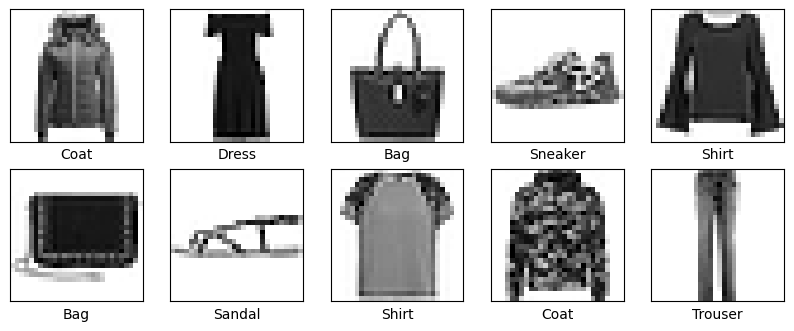

In [5]:
# Check 10 random training example
plt.figure(figsize=(10, 10))
# create random choices
random_indices = np.random.choice(len(train_images), size=10, replace=False)
for i,j in enumerate(random_indices):
    plt.subplot(5, 5, i + 1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(train_images[j].numpy().squeeze(), cmap=plt.cm.binary)
    plt.xlabel(dict_labels[train_labels[j]])
plt.show()



## Create image data augmentation

In [6]:
# Image Augmentation
def create_image_augmentation(horizontal_flip = False, rotation = 0, brightness = 0, zoom = 0, translation = 0):
  data_augmentation = tf.keras.Sequential()
  if horizontal_flip:
    data_augmentation.add(RandomFlip("horizontal"))
  data_augmentation.add(RandomRotation(rotation,fill_mode="constant",fill_value=0))
  data_augmentation.add(RandomBrightness(brightness))
  data_augmentation.add(RandomZoom(zoom,fill_mode="constant",fill_value=0))
  data_augmentation.add(RandomTranslation(translation, translation,fill_mode="constant",fill_value = 0))
  return data_augmentation


# Test image augmentation pipeline

In [7]:
input_layer = Input(shape=(28,28,1))
x = create_image_augmentation(horizontal_flip = True, rotation = 0.2, brightness = 0.001, zoom = 0.1, translation = 0.1)(input_layer)

model = Model(inputs=input_layer, outputs=x)
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 28, 28, 1)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Prediction shape: (10, 28, 28, 1)


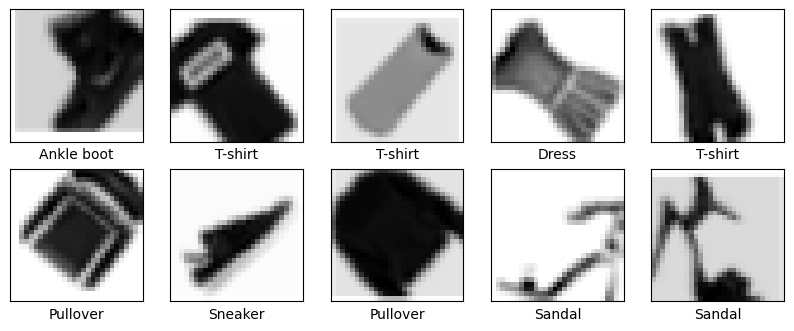

In [8]:
pred = model(train_images[:10])
print(f"Prediction shape: {pred.shape}")
plt.figure(figsize=(10, 10))
for i in range(10):
    plt.subplot(5, 5, i + 1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(pred[i,:,:,0].numpy().squeeze(), cmap=plt.cm.binary)
    plt.xlabel(dict_labels[train_labels[i]])
plt.show()

# Create base model
This will allow to select how many conv layers and dense layers we want

In [9]:
def core_fashion_model(N_conv = 2 , N_dense = 2, kernel_size = 3, global_pooling_type = "max"):
  # validate arguments
  if N_conv < 1:
    raise ValueError("N_conv must be greater than 0")
  if N_dense < 1:
    raise ValueError("N_dense must be greater than 0")
  input_layer = Input(shape=(28,28,1))
  for i in range(N_conv):
    if i == 0:
      x = Conv2D(32, kernel_size, strides=1)(input_layer) # Removed activation
    else:
      x = Conv2D(32*(i*2), kernel_size,strides=1)(x) # Removed activation
    x = BatchNormalization()(x) # Added BatchNormalization
    x = Activation('relu')(x) # Added Activation after BatchNormalization
  if global_pooling_type == "max":
    x = GlobalMaxPool2D()(x)
  elif global_pooling_type == "avg":
    x = GlobalAvgPool2D()(x)
  elif global_pooling_type == "flatten":
    x = Flatten()(x)
  else:
    raise ValueError("global_pooling_type must be either 'max', 'avg' or 'flatten'")
  x = Dropout(0.5)(x)
  for i in range(N_dense):
    x = Dense(64, kernel_regularizer="l2")(x) # Removed activation
    x = BatchNormalization()(x) # Added BatchNormalization
    x = Activation('relu')(x) # Added Activation after BatchNormalization
    x = Dropout(0.2)(x)
  output = Dense(10, activation='softmax')(x)
  model = Model(inputs=input_layer, outputs=output)
  return model

In [10]:
core_model = core_fashion_model(N_conv = 3 , N_dense = 2, kernel_size = 3, global_pooling_type = "max")
core_model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 26, 26, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 26, 26, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 24, 24, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 24, 24, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 22, 22, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 22, 22, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 22, 22, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling2d            │ (None, 128)            │             0 │
│ (GlobalMaxPooling2D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 107,146 (418.54 KB)

 Trainable params: 106,442 (415.79 KB)

 Non-trainable params: 704 (2.75 KB)

# Define Training Model

In [11]:
# flush unused tensorflow models
tf.keras.backend.clear_session()

# Setup Augmentation model
aug_input = Input(shape=(28,28,1))
aug_model = create_image_augmentation(horizontal_flip = True, rotation = 0.1, brightness = 0.001, zoom = 0.1, translation = 0.1)(aug_input)

# Create core model
core_model = core_fashion_model(N_conv = 4 , N_dense = 2, kernel_size = 3, global_pooling_type = "flatten")

# Join core model and augmentation pipeline -> This helps with GPU image augmentation
training_outputs = core_model(aug_model)

# Create training model
training_model = Model(inputs=aug_input, outputs=training_outputs)

# Create optimizer
optimizer = Adam(learning_rate=0.001)

# Compile and select optimizer
training_model.compile(optimizer=optimizer, loss='sparse_categorical_crossentropy', metrics=['accuracy'])
# Show training model summary
training_model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ functional_1 (Functional)       │ (None, 10)             │     5,236,298 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,236,298 (19.97 MB)

 Trainable params: 5,235,210 (19.97 MB)

 Non-trainable params: 1,088 (4.25 KB)

# Train Model

In [12]:
# Train model
hist = training_model.fit(train_images, train_labels, batch_size=512, epochs=200, validation_data=(val_images, val_labels),
                          callbacks=[EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
                                     ReduceLROnPlateau(monitor='val_loss', factor=0.1, patience=3),
                                     ModelCheckpoint("best_model.keras", monitor='val_loss', save_best_only=True)])
#

Epoch 1/200
106/106 ━━━━━━━━━━━━━━━━━━━━ 38s 249ms/step - accuracy: 0.6285 - loss: 2.3936 - val_accuracy: 0.1333 - val_loss: 3.0802 - learning_rate: 0.0010
Epoch 2/200
106/106 ━━━━━━━━━━━━━━━━━━━━ 22s 210ms/step - accuracy: 0.7192 - loss: 1.4105 - val_accuracy: 0.3572 - val_loss: 2.3489 - learning_rate: 0.0010
Epoch 3/200
106/106 ━━━━━━━━━━━━━━━━━━━━ 22s 206ms/step - accuracy: 0.7424 - loss: 1.2443 - val_accuracy: 0.5972 - val_loss: 1.6982 - learning_rate: 0.0010
Epoch 4/200
106/106 ━━━━━━━━━━━━━━━━━━━━ 22s 207ms/step - accuracy: 0.7544 - loss: 1.1919 - val_accuracy: 0.6955 - val_loss: 1.4137 - learning_rate: 0.0010
Epoch 5/200
106/106 ━━━━━━━━━━━━━━━━━━━━ 22s 211ms/step - accuracy: 0.7683 - loss: 1.1510 - val_accuracy: 0.7288 - val_loss: 1.2074 - learning_rate: 0.0010
Epoch 6/200
106/106 ━━━━━━━━━━━━━━━━━━━━ 22s 211ms/step - accuracy: 0.7745 - loss: 1.1433 - val_accuracy: 0.8005 - val_loss: 1.0694 - learning_rate: 0.0010
Epoch 7/200
106/106 ━━━━━━━━━━━━━━━━━━━━ 23s 213ms/step - accura

In [13]:
# Evaluate model
# TODO: Load the best model saved during training for evaluation
# We can not use the full model because it has image augmentation
best_model = tf.keras.models.load_model("best_model.keras")
best_model.summary()

# Evaluate the best trained model on the test dataset
test_loss, test_acc = best_model.evaluate(test_images, test_labels)
print(f"Test accuracy: {test_acc}")
print(f"Test loss: {test_loss}")

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ functional_1 (Functional)       │ (None, 10)             │     5,236,298 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,706,720 (59.92 MB)

 Trainable params: 5,235,210 (19.97 MB)

 Non-trainable params: 1,088 (4.25 KB)

 Optimizer params: 10,470,422 (39.94 MB)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.8857 - loss: 0.3972
Test accuracy: 0.885699987411499
Test loss: 0.39724454283714294
